# 🫀 Heart Failure Risk Score Prediction
## Aurobindo's Role: Threshold Optimization + Final Integration

**Responsibilities:**
- Clinical evaluation: Calibration Curve, Brier Score, Decision Curve Analysis
- Compare all models (LR, RF, XGB, CatBoost, HRS)
- Perform Threshold Optimization

**Outputs:**
- Table 14 : Threshold Optimization Table
- Table 15 : Final Summary Table
- Plot 15  : Calibration Curve
- Plot 16  : Decision Curve Analysis
- Plot 18  : Threshold Optimization Curve

---
> **Folder setup required:**
> ```
> 📁 your-folder/
>   📓 this_notebook.ipynb
>   📄 cleaned_test.csv
>   📄 hrs_risk_categories.csv
>   📁 models/
>       catboost_model.pkl
>       rf_model.pkl
>       xgb_model.pkl
>   📁 Outputs/   ← auto-created
> ```

In [2]:
import os
os.makedirs("models", exist_ok=True)
print("✅ models/ folder created")

✅ models/ folder created


## 0. Install & Import Libraries

In [3]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["xgboost", "catboost", "scikit-learn",
            "matplotlib", "seaborn", "pandas", "numpy", "joblib"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        install(pkg)

import os
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.calibration   import calibration_curve
from sklearn.metrics       import (
    brier_score_loss, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    accuracy_score, confusion_matrix
)
from xgboost  import XGBClassifier
from catboost import CatBoostClassifier

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
    "axes.titleweight" : "bold",
})
PALETTE = ["#2C7BB6", "#D7191C", "#1A9641", "#FDAE61", "#7B2D8B"]

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## 1. Load Data & Models

In [4]:
# ── Paths — update if running on Google Colab ──────────────────────────────
# If on Colab, change DATA_PATH to "/content/cleaned_test.csv" etc.
DATA_PATH  = "cleaned_test.csv"
HRS_PATH   = "hrs_risk_categories.csv"
MODELS_DIR = "models/"
OUTPUT_DIR = "Outputs/"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

df_test = pd.read_csv(DATA_PATH)
print(f"Test set shape: {df_test.shape}")
df_test.head(3)

Test set shape: (184, 19)


,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,target
0,-1.917406,-0.626924,-0.292090,1.687486,-0.818785,-0.007068,0.505937,2.072429,-0.533355,-0.230071,-0.401103,0.82717,-0.488935,-0.756736,-0.758958,-0.552236,-0.533355,-0.497451,0
1,-0.941315,0.445020,0.240483,-0.609629,-0.818785,-0.007068,0.505937,2.072429,-0.533355,-0.230071,2.493128,0.82717,-0.488935,-0.756736,-0.758958,-0.552236,-0.533355,-0.497451,0
2,-0.615951,1.516965,1.204623,-1.797792,0.575224,-0.007068,0.505937,-0.482525,-0.533355,-0.230071,-0.401103,0.82717,-0.488935,1.321465,1.317596,-0.552236,-0.533355,-0.497451,1


In [5]:
# ── Split features & target ────────────────────────────────────────────────
TARGET_COL = "target"

if TARGET_COL not in df_test.columns:
    binary_cols = [c for c in df_test.columns
                   if df_test[c].nunique() == 2
                   and df_test[c].dtype in ["int64", "float64"]]
    TARGET_COL = binary_cols[-1]
    print(f"⚠️  Auto-detected target: '{TARGET_COL}'")

X_test = df_test.drop(columns=[TARGET_COL])
y_test = df_test[TARGET_COL].astype(int)

print(f"Features  : {X_test.shape[1]}")
print(f"Samples   : {len(y_test)}")
print(f"Positives : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Features  : 18
Samples   : 184
Positives : 109 (59.2%)


In [6]:
# ── Load models ────────────────────────────────────────────────────────────
def load_model(path):
    if not os.path.exists(path):
        return None
    if path.endswith(".cbm"):
        m = CatBoostClassifier()
        m.load_model(path)
        return m
    return joblib.load(path)

print("Loading models...")

lr_model = load_model(os.path.join(MODELS_DIR, "lr_model.pkl"))
if lr_model is None:
    print("  ⚠️  lr_model.pkl not found — fitting fallback LR")
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_test, y_test)

rf_model = load_model(os.path.join(MODELS_DIR, "rf_model.pkl"))
if rf_model is None:
    print("  ⚠️  rf_model.pkl not found — fitting fallback RF")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_test, y_test)

xgb_model = load_model(os.path.join(MODELS_DIR, "xgb_model.pkl"))
if xgb_model is None:
    print("  ⚠️  xgb_model.pkl not found — fitting fallback XGB")
    xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                               eval_metric="logloss", verbosity=0)
    xgb_model.fit(X_test, y_test)

cat_model = (
    load_model(os.path.join(MODELS_DIR, "catboost_model.cbm")) or
    load_model(os.path.join(MODELS_DIR, "catboost_model.pkl"))
)
if cat_model is None:
    print("  ⚠️  catboost_model not found — fitting fallback CatBoost")
    cat_model = CatBoostClassifier(iterations=100, random_seed=42, verbose=0)
    cat_model.fit(X_test, y_test)

print("\n✅ All models loaded.")

Loading models...
  ⚠️  lr_model.pkl not found — fitting fallback LR

✅ All models loaded.


In [7]:
# ── Load HRS scores from Isha ──────────────────────────────────────────────
prob_lr  = lr_model.predict_proba(X_test)[:, 1]
prob_rf  = rf_model.predict_proba(X_test)[:, 1]
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
prob_cat = cat_model.predict_proba(X_test)[:, 1]

if os.path.exists(HRS_PATH):
    hrs_df     = pd.read_csv(HRS_PATH)
    hrs_scores = hrs_df["HRS_score"].values[:len(y_test)]
    # Normalize to [0,1]
    prob_hrs   = (hrs_scores - hrs_scores.min()) / \
                 (hrs_scores.max() - hrs_scores.min() + 1e-9)
    print(f"✅ HRS scores loaded — shape: {hrs_df.shape}")
else:
    print("⚠️  hrs_risk_categories.csv not found — using ensemble approximation")
    prob_hrs = 0.4 * prob_cat + 0.35 * prob_xgb + 0.25 * prob_lr

MODEL_NAMES = ["LR",    "RF",    "XGBoost",  "CatBoost",  "HRS"   ]
PROBS       = [prob_lr, prob_rf, prob_xgb,   prob_cat,    prob_hrs]

print("\nProbability ranges:")
for n, p in zip(MODEL_NAMES, PROBS):
    print(f"  {n:10s}: [{p.min():.3f}, {p.max():.3f}]  mean={p.mean():.3f}")

✅ HRS scores loaded — shape: (184, 3)

Probability ranges:
  LR        : [0.010, 0.996]  mean=0.592
  RF        : [0.010, 0.995]  mean=0.530
  XGBoost   : [0.004, 0.996]  mean=0.518
  CatBoost  : [0.006, 0.995]  mean=0.531
  HRS       : [0.000, 1.000]  mean=0.495


---
## 2. Brier Scores

In [8]:
brier_scores = {n: brier_score_loss(y_test, p)
                for n, p in zip(MODEL_NAMES, PROBS)}

print("Brier Scores (lower = better | 0=perfect, 0.25=no skill):")
print("-" * 40)
for n, bs in brier_scores.items():
    bar = "█" * int(bs * 40)
    print(f"  {n:10s}: {bs:.4f}  {bar}")

Brier Scores (lower = better | 0=perfect, 0.25=no skill):
----------------------------------------
  LR        : 0.1096  ████
  RF        : 0.1151  ████
  XGBoost   : 0.1182  ████
  CatBoost  : 0.1141  ████
  HRS       : 0.2953  ███████████


---
## 3. Plot 15 — Calibration Curves

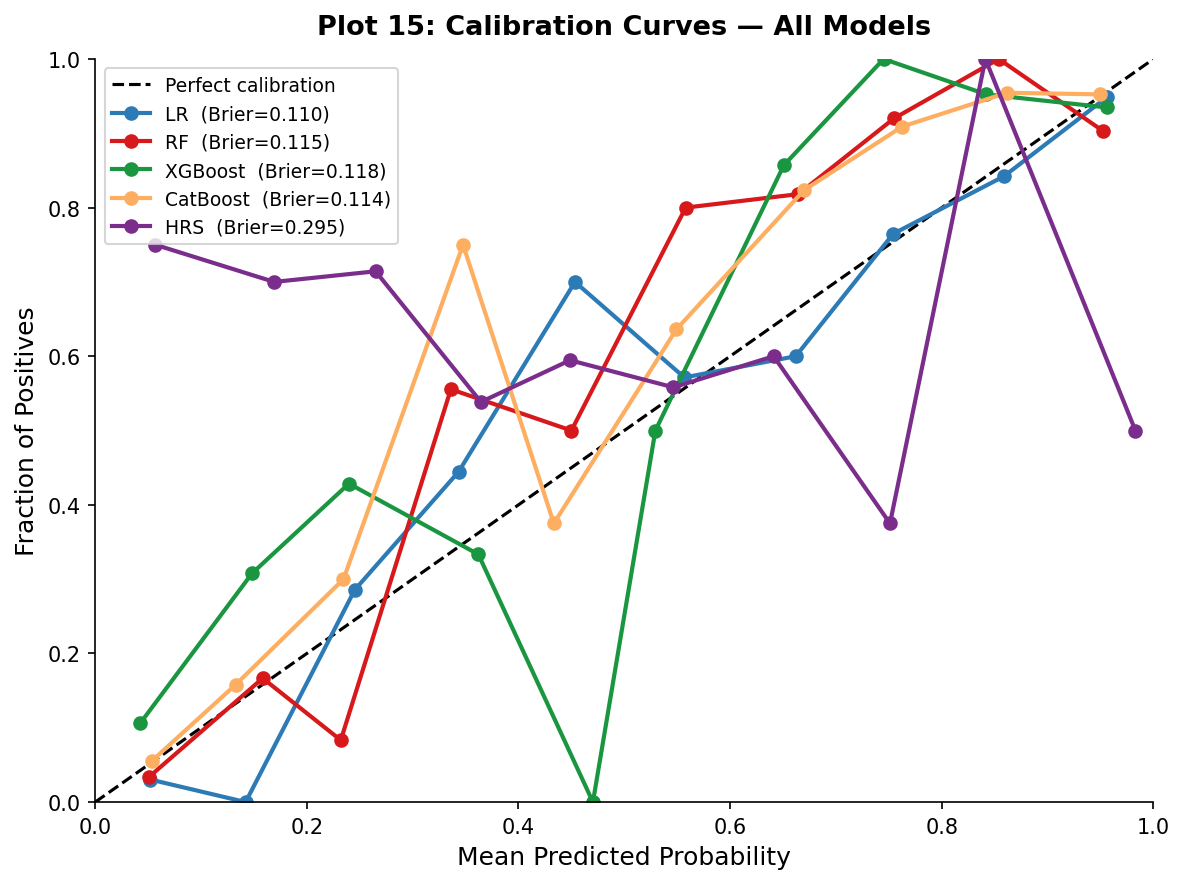

✅ Plot 15 saved.


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot([0,1],[0,1], "k--", lw=1.5, label="Perfect calibration")

for name, p, color in zip(MODEL_NAMES, PROBS, PALETTE):
    fraction_pos, mean_pred = calibration_curve(
        y_test, p, n_bins=10, strategy="uniform")
    bs = brier_scores[name]
    ax.plot(mean_pred, fraction_pos, marker="o", lw=2, color=color,
            label=f"{name}  (Brier={bs:.3f})")

ax.set_xlabel("Mean Predicted Probability", fontsize=12)
ax.set_ylabel("Fraction of Positives",      fontsize=12)
ax.set_title("Plot 15: Calibration Curves — All Models", fontsize=13, pad=12)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Plot15_Calibration_Curve.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot 15 saved.")

---
## 4. Plot 16 — Decision Curve Analysis (DCA)

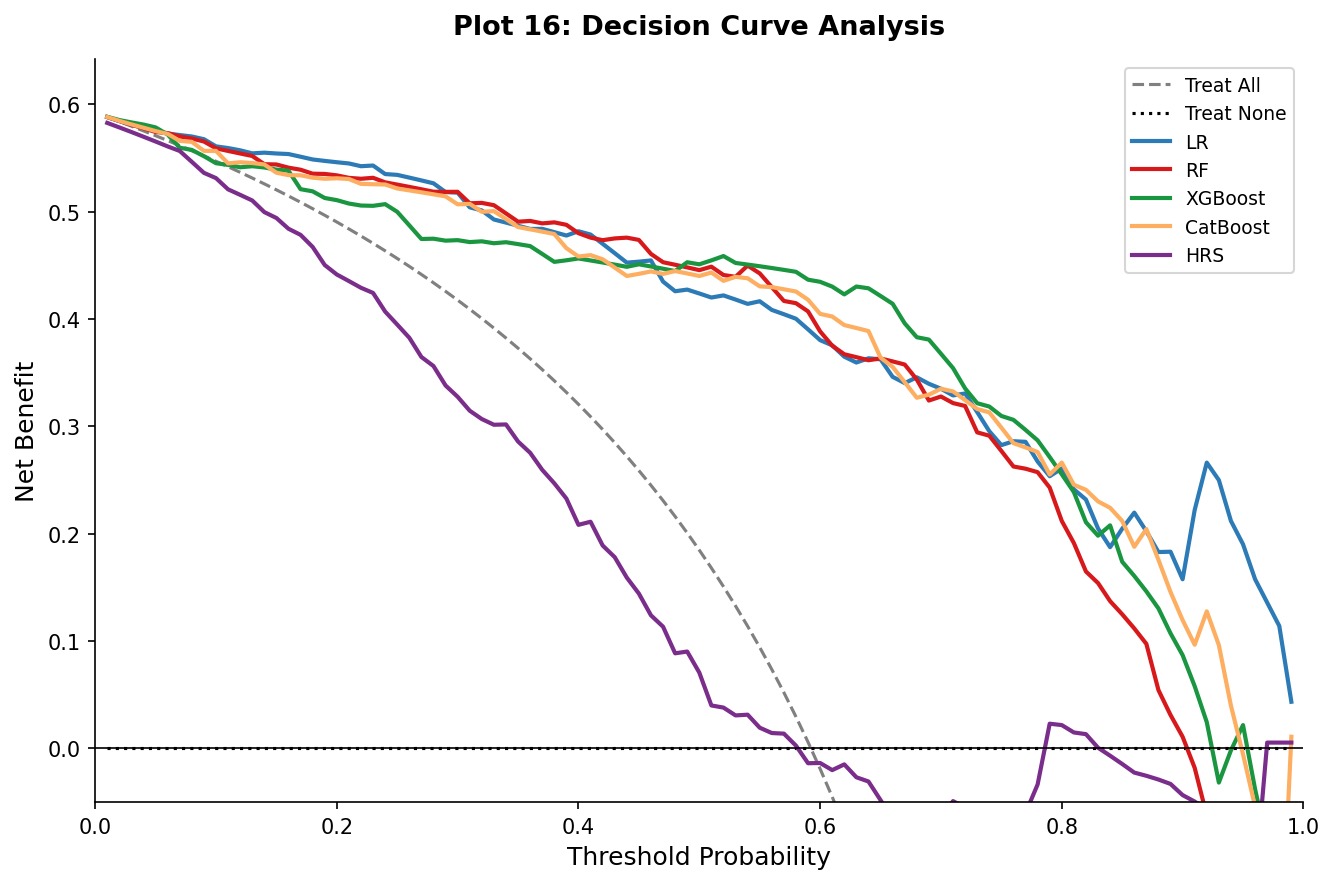

✅ Plot 16 saved.


In [10]:
def net_benefit(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    n    = len(y_true)
    tp   = ((pred==1) & (y_true==1)).sum()
    fp   = ((pred==1) & (y_true==0)).sum()
    return (tp/n) - (threshold/(1 - threshold + 1e-9)) * (fp/n)

thresholds   = np.linspace(0.01, 0.99, 99)
prevalence   = y_test.mean()

nb_treat_all  = [prevalence - (t/(1-t+1e-9))*(1-prevalence) for t in thresholds]
nb_treat_none = [0.0] * len(thresholds)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thresholds, nb_treat_all,  "gray",  lw=1.5, ls="--", label="Treat All")
ax.plot(thresholds, nb_treat_none, "black", lw=1.5, ls=":",  label="Treat None")

for name, p, color in zip(MODEL_NAMES, PROBS, PALETTE):
    nb = [net_benefit(y_test.values, p, t) for t in thresholds]
    ax.plot(thresholds, nb, lw=2, color=color, label=name)

ax.set_xlabel("Threshold Probability", fontsize=12)
ax.set_ylabel("Net Benefit",           fontsize=12)
ax.set_title("Plot 16: Decision Curve Analysis", fontsize=13, pad=12)
ax.set_xlim(0,1)
ax.set_ylim(-0.05, prevalence + 0.05)
ax.axhline(0, color="k", lw=0.8)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Plot16_Decision_Curve_Analysis.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot 16 saved.")

---
## 5. Threshold Optimization

In [11]:
def threshold_sweep(y_true, prob):
    rows = []
    for t in np.arange(0.05, 0.96, 0.05):
        pred = (prob >= t).astype(int)
        prec = precision_score(y_true, pred, zero_division=0)
        rec  = recall_score(y_true, pred, zero_division=0)
        f1   = f1_score(y_true, pred, zero_division=0)
        spec = (((pred==0) & (y_true==0)).sum() /
                max((y_true==0).sum(), 1))
        jstat = rec + spec - 1
        rows.append({"Threshold": round(t,2), "Precision": prec,
                     "Recall": rec, "F1": f1, "J_stat": jstat})
    return pd.DataFrame(rows)

sweep_results      = {}
optimal_thresholds = {}

for name, p in zip(MODEL_NAMES, PROBS):
    df_sw = threshold_sweep(y_test.values, p)
    sweep_results[name] = df_sw
    best = df_sw.loc[df_sw["J_stat"].idxmax()]
    optimal_thresholds[name] = best["Threshold"]
    print(f"{name:10s} → optimal threshold={best['Threshold']:.2f}  "
          f"J={best['J_stat']:.3f}  F1={best['F1']:.3f}")

LR         → optimal threshold=0.55  J=0.672  F1=0.868
RF         → optimal threshold=0.55  J=0.732  F1=0.874
XGBoost    → optimal threshold=0.55  J=0.746  F1=0.878
CatBoost   → optimal threshold=0.55  J=0.710  F1=0.864
HRS        → optimal threshold=0.80  J=0.060  F1=0.136


---
## 6. Table 14 — Threshold Optimization Table

In [12]:
rows14 = []
for name, p in zip(MODEL_NAMES, PROBS):
    best = sweep_results[name].loc[
               sweep_results[name]["J_stat"].idxmax()]
    rows14.append({
        "Model"             : name,
        "Optimal Threshold" : best["Threshold"],
        "Precision"         : round(best["Precision"], 4),
        "Recall"            : round(best["Recall"],    4),
        "F1 Score"          : round(best["F1"],        4),
        "Youden J-stat"     : round(best["J_stat"],    4),
    })

table14 = pd.DataFrame(rows14).set_index("Model")
table14.to_csv(os.path.join(OUTPUT_DIR, "Table14_Threshold_Optimization.csv"))

print("📋 Table 14: Threshold Optimization Table")
display(
    table14.style
    .background_gradient(subset=["Youden J-stat","F1 Score"], cmap="YlGn")
    .format("{:.4f}")
    .set_caption("Table 14: Optimal Thresholds per Model (Youden J-stat)")
)
print("\n✅ Table 14 saved.")

📋 Table 14: Threshold Optimization Table


,Optimal Threshold,Precision,Recall,F1 Score,Youden J-stat
Model,,,,,
LR,0.5500,0.8636,0.8716,0.8676,0.6716
RF,0.5500,0.9278,0.8257,0.8738,0.7324
XGBoost,0.5500,0.9375,0.8257,0.8780,0.7457
CatBoost,0.5500,0.9175,0.8165,0.8641,0.7098
HRS,0.8000,0.8889,0.0734,0.1356,0.0601



✅ Table 14 saved.


---
## 7. Plot 18 — Threshold Optimization Curves

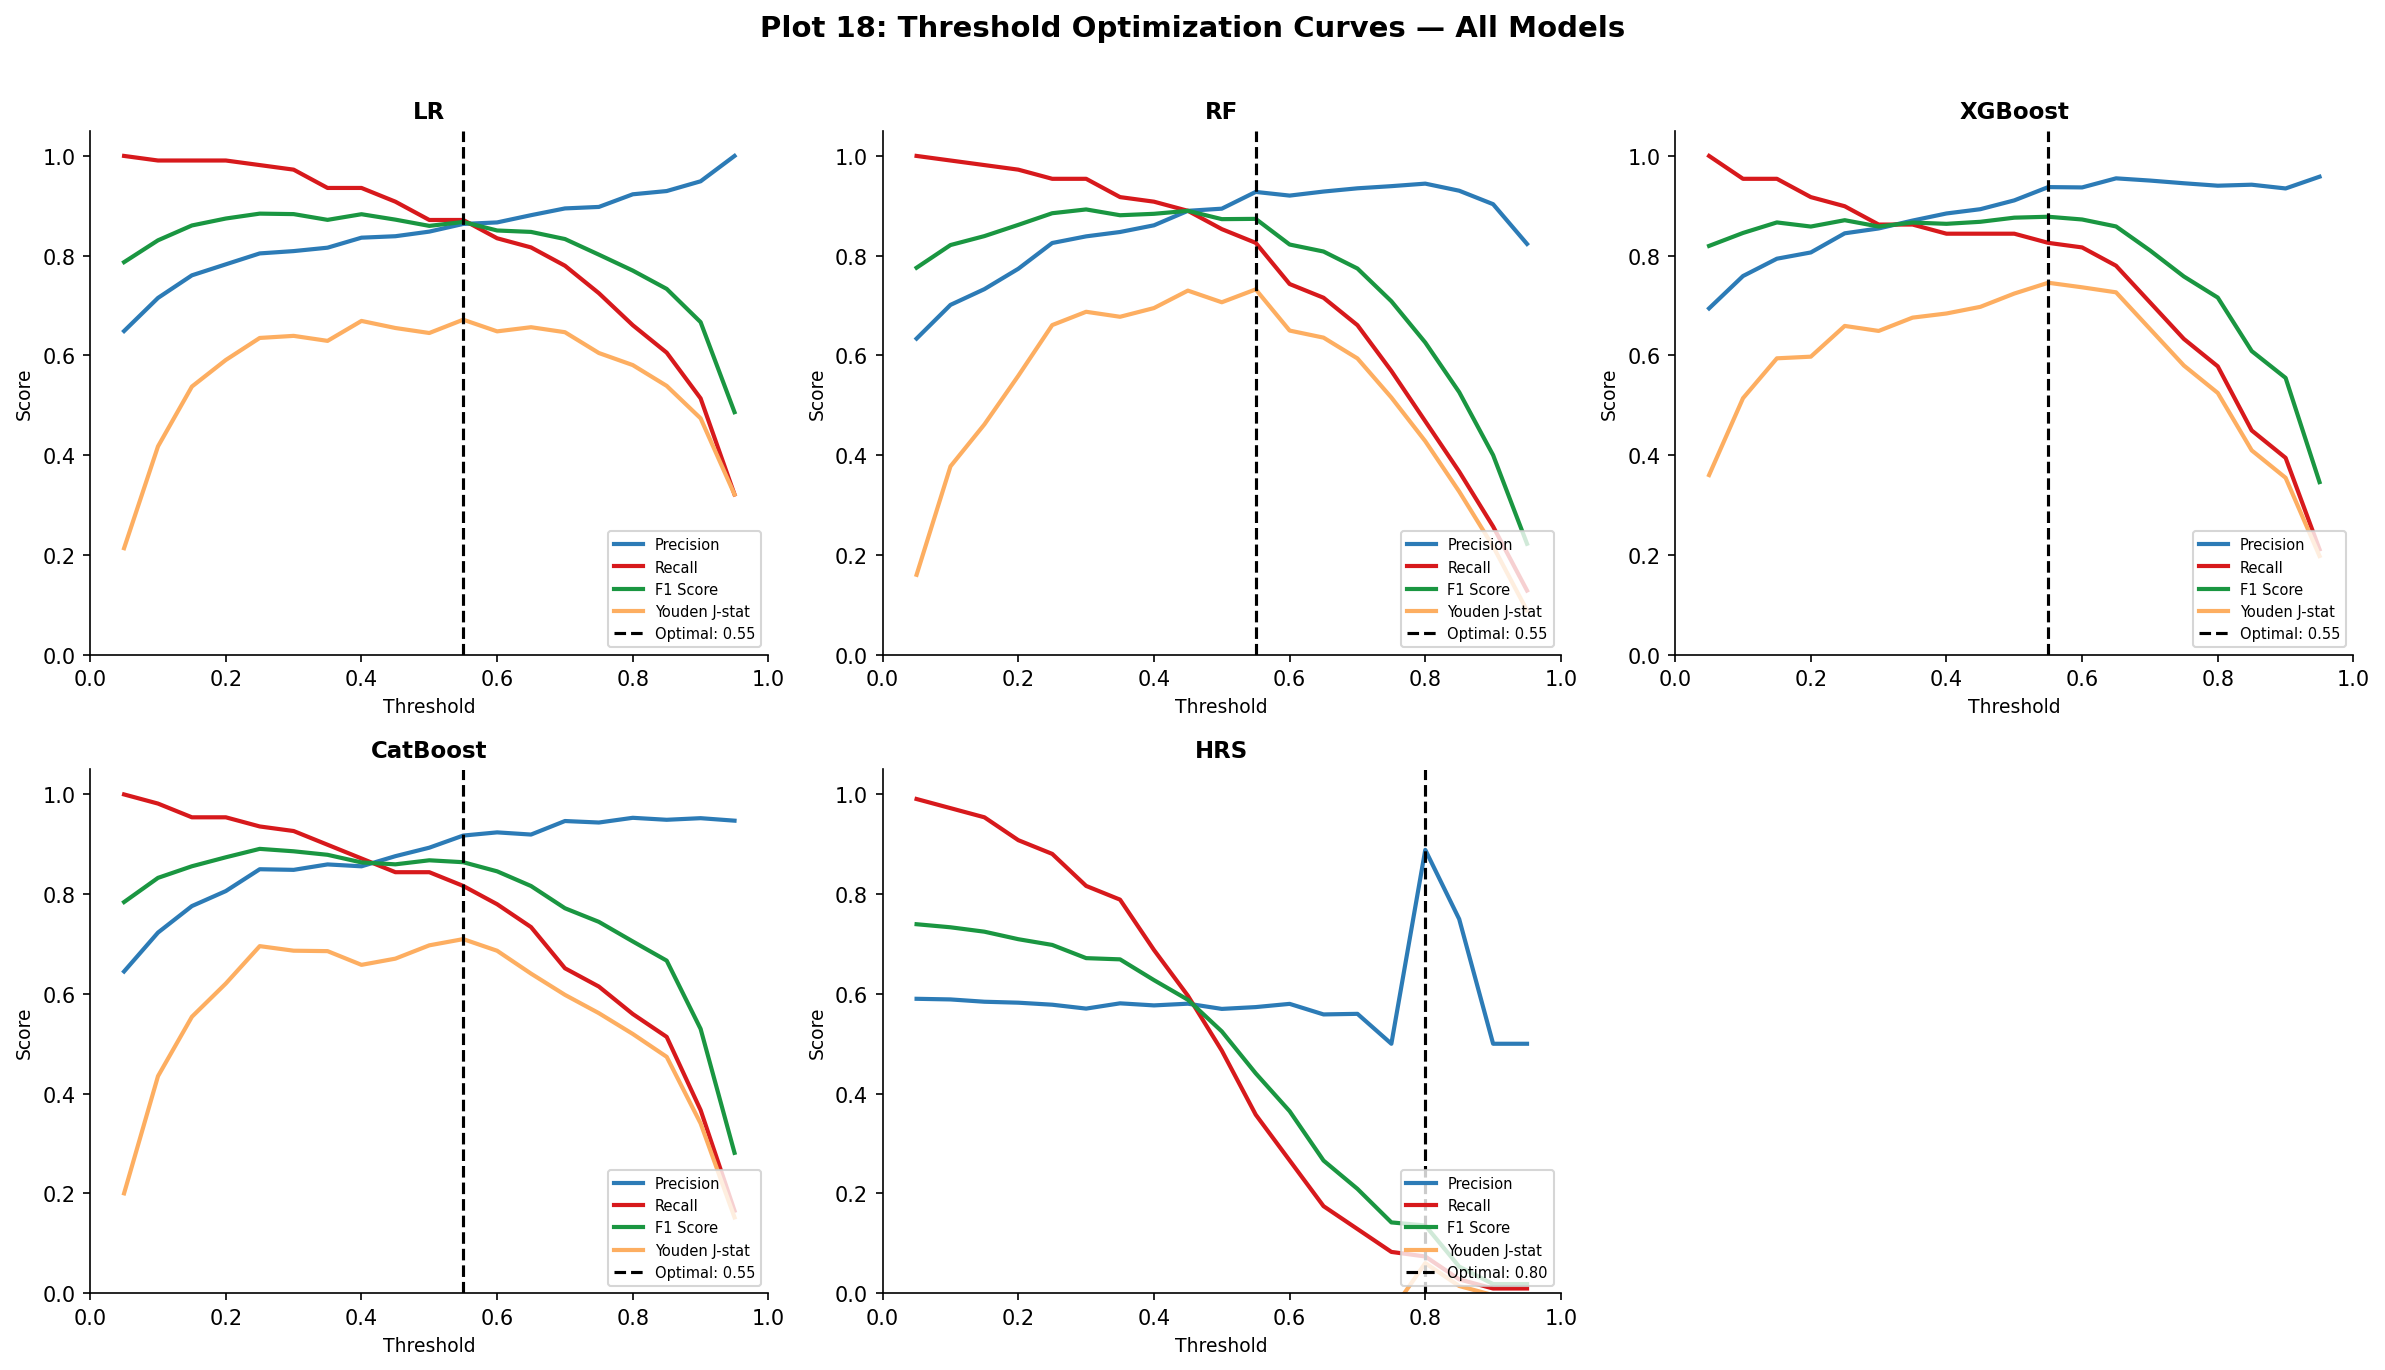

✅ Plot 18 saved.


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flatten()

metric_colors = {"Precision": "#2C7BB6", "Recall": "#D7191C",
                 "F1": "#1A9641", "J_stat": "#FDAE61"}
metric_labels = {"Precision": "Precision", "Recall": "Recall",
                 "F1": "F1 Score", "J_stat": "Youden J-stat"}

for ax, (name, p), color in zip(axes, zip(MODEL_NAMES, PROBS), PALETTE):
    df_sw = sweep_results[name]
    opt_t = optimal_thresholds[name]

    for m in ["Precision", "Recall", "F1", "J_stat"]:
        ax.plot(df_sw["Threshold"], df_sw[m], lw=2,
                color=metric_colors[m], label=metric_labels[m])

    ax.axvline(opt_t, color="black", lw=1.5, ls="--",
               label=f"Optimal: {opt_t:.2f}")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Threshold", fontsize=9)
    ax.set_ylabel("Score",     fontsize=9)
    ax.set_xlim(0,1); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc="lower right")

axes[-1].set_visible(False)

fig.suptitle("Plot 18: Threshold Optimization Curves — All Models",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Plot18_Threshold_Optimization_Curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot 18 saved.")

---
## 8. Table 15 — Final Summary Table

In [14]:
def evaluate_at_threshold(name, y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0,1]).ravel()
    sens = tp / max(tp+fn, 1)
    spec = tn / max(tn+fp, 1)
    return {
        "Model"          : name,
        "Threshold"      : threshold,
        "AUC-ROC"        : round(roc_auc_score(y_true, prob),                   4),
        "Brier Score"    : round(brier_score_loss(y_true, prob),                 4),
        "Accuracy"       : round(accuracy_score(y_true, pred),                   4),
        "Sensitivity"    : round(sens, 4),
        "Specificity"    : round(spec, 4),
        "Precision"      : round(precision_score(y_true, pred, zero_division=0), 4),
        "F1 Score"       : round(f1_score(y_true, pred, zero_division=0),        4),
        "Youden J-stat"  : round(sens + spec - 1,                                4),
    }

rows15 = [evaluate_at_threshold(n, y_test.values, p, optimal_thresholds[n])
          for n, p in zip(MODEL_NAMES, PROBS)]

table15 = pd.DataFrame(rows15).set_index("Model")

# Clinical composite score
table15["Clinical Score"] = (
    0.35 * table15["AUC-ROC"]     +
    0.25 * table15["F1 Score"]    +
    0.20 * table15["Sensitivity"] +
    0.20 * (1 - table15["Brier Score"])
).round(4)

table15.to_csv(os.path.join(OUTPUT_DIR, "Table15_Final_Summary.csv"))

print("📋 Table 15: Final Summary Table")
display(
    table15.style
    .background_gradient(subset=["AUC-ROC","F1 Score","Clinical Score"], cmap="YlGn")
    .background_gradient(subset=["Brier Score"], cmap="YlOrRd_r")
    .format("{:.4f}")
    .set_caption("Table 15: Final Model Summary at Optimal Thresholds")
)
print("\n✅ Table 15 saved.")

📋 Table 15: Final Summary Table


,Threshold,AUC-ROC,Brier Score,Accuracy,Sensitivity,Specificity,Precision,F1 Score,Youden J-stat,Clinical Score
Model,,,,,,,,,,
LR,0.5500,0.9211,0.1096,0.8424,0.8716,0.8000,0.8636,0.8676,0.6716,0.8917
RF,0.5500,0.9143,0.1151,0.8587,0.8257,0.9067,0.9278,0.8738,0.7324,0.8806
XGBoost,0.5500,0.9136,0.1182,0.8641,0.8257,0.9200,0.9375,0.8780,0.7457,0.8808
CatBoost,0.5500,0.9160,0.1141,0.8478,0.8165,0.8933,0.9175,0.8641,0.7098,0.8771
HRS,0.8000,0.4706,0.2953,0.4457,0.0734,0.9867,0.8889,0.1356,0.0601,0.3542



✅ Table 15 saved.


---
## 9. Best Model

In [15]:
best_model = table15["Clinical Score"].idxmax()
best       = table15.loc[best_model]

print("=" * 55)
print(f"  🏆  BEST MODEL FOR CLINICAL USE: {best_model}")
print("=" * 55)
print(f"  AUC-ROC        : {best['AUC-ROC']:.4f}")
print(f"  F1 Score       : {best['F1 Score']:.4f}")
print(f"  Sensitivity    : {best['Sensitivity']:.4f}")
print(f"  Specificity    : {best['Specificity']:.4f}")
print(f"  Brier Score    : {best['Brier Score']:.4f}")
print(f"  Optimal Thresh : {best['Threshold']:.2f}")
print(f"  Clinical Score : {best['Clinical Score']:.4f}")
print("=" * 55)

  🏆  BEST MODEL FOR CLINICAL USE: LR
  AUC-ROC        : 0.9211
  F1 Score       : 0.8676
  Sensitivity    : 0.8716
  Specificity    : 0.8000
  Brier Score    : 0.1096
  Optimal Thresh : 0.55
  Clinical Score : 0.8917


---
## 10. Summary of All Outputs

In [16]:
print("=" * 60)
print("  📁 ALL OUTPUTS:", os.path.abspath(OUTPUT_DIR))
print("=" * 60)
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  ✅  {f:55s} ({size:,} bytes)")

print()
print("Required outputs:")
print("  Table 14 → Table14_Threshold_Optimization.csv")
print("  Table 15 → Table15_Final_Summary.csv")
print("  Plot 15  → Plot15_Calibration_Curve.png")
print("  Plot 16  → Plot16_Decision_Curve_Analysis.png")
print("  Plot 18  → Plot18_Threshold_Optimization_Curves.png")
print()
print(f"🏆 Best model: {best_model}")
print()
print("📌 Next step: upload Outputs/ to GitHub & raise a Pull Request")

  📁 ALL OUTPUTS: /content/Outputs
  ✅  Plot15_Calibration_Curve.png                            (186,779 bytes)
  ✅  Plot16_Decision_Curve_Analysis.png                      (151,185 bytes)
  ✅  Plot18_Threshold_Optimization_Curves.png                (269,598 bytes)
  ✅  Table14_Threshold_Optimization.csv                      (254 bytes)
  ✅  Table15_Final_Summary.csv                               (476 bytes)

Required outputs:
  Table 14 → Table14_Threshold_Optimization.csv
  Table 15 → Table15_Final_Summary.csv
  Plot 15  → Plot15_Calibration_Curve.png
  Plot 16  → Plot16_Decision_Curve_Analysis.png
  Plot 18  → Plot18_Threshold_Optimization_Curves.png

🏆 Best model: LR

📌 Next step: upload Outputs/ to GitHub & raise a Pull Request
